# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys 
sys.path.append(r"C:\Users\User\mlpractical")

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [2]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [4]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.
import os
os.environ['MLP_DATA_DIR'] = r'C:\Users\User\mlpractical\data'

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile 'C:\\Users\\User\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\User\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 6.8s to complete
    error(train)=7.72e-01, acc(train)=7.60e-01, error(valid)=7.87e-01, acc(valid)=7.58e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 98: 6.6s to complete
    error(train)=8.75e-02, acc(train)=9.64e-01, error(valid)=1.52e+00, acc(valid)=8.16e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 6.6s to complete
    error(train)=1.11e-01, acc(train)=9.56e-01, error(valid)=1.59e+00, acc(valid)=8.15e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 6.6s to complete
    error(train)=9.95e-02, acc(train)=9.60e-01, error(valid)=1.56e+00, acc(valid)=8.17e-01


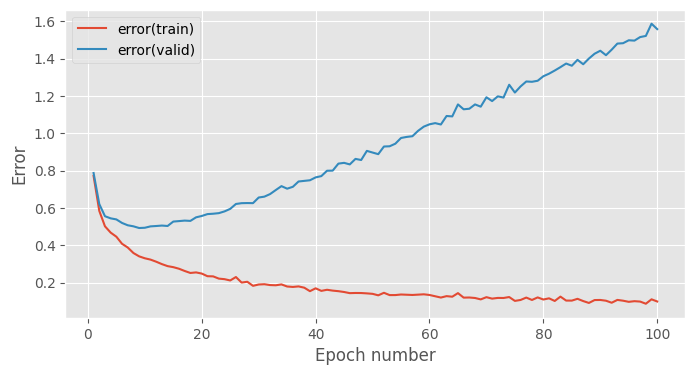

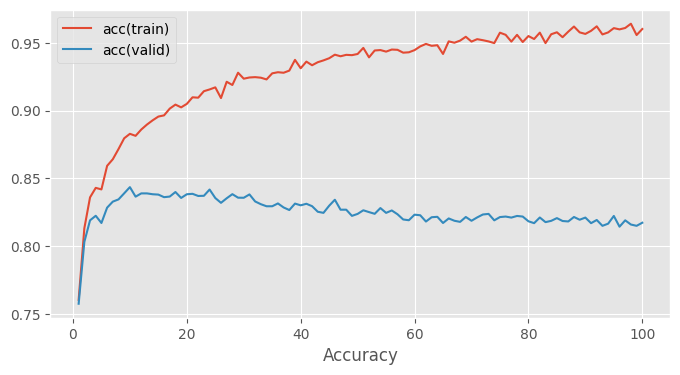

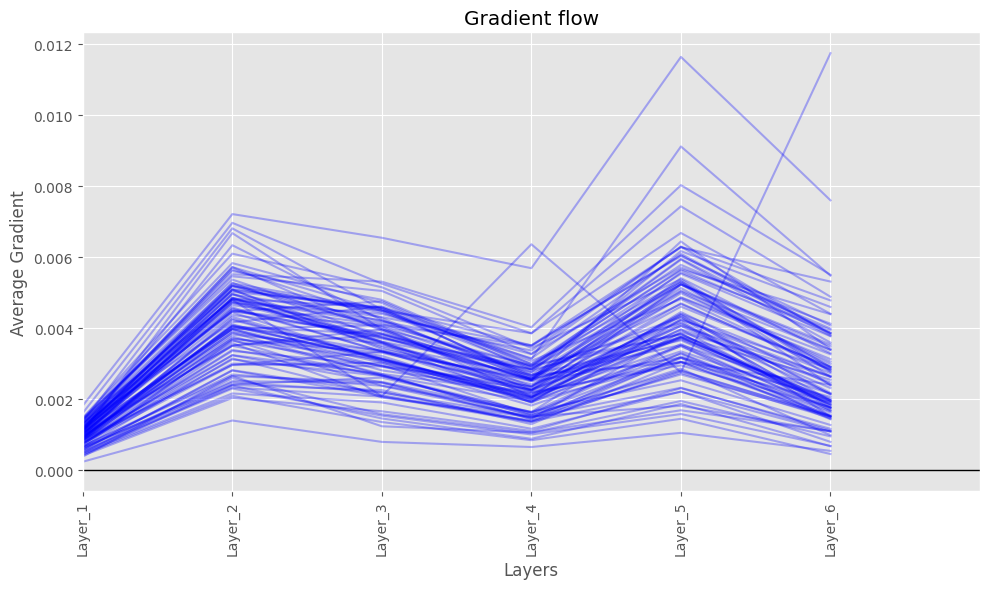

In [5]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## TRIAL

In [12]:
def train_model(model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    data_monitors={'acc':lambda y,t: (y.argmax(-1) == t.argmax(-1)).mean()}
    
    optimiser = Optimiser(model,error,learning_rule,train_data,valid_data,data_monitors,notebook=notebook)
    
    stats,keys,run_time = optimiser.train(num_epochs=num_epochs,stats_interval=stats_interval)
    
    return stats,keys

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.9s to complete
    error(train)=8.38e-01, acc(train)=7.50e-01, error(valid)=8.56e-01, acc(valid)=7.48e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.9s to complete
    error(train)=6.57e-01, acc(train)=7.95e-01, error(valid)=6.91e-01, acc(valid)=7.86e-01


...

Epoch 98: 2.3s to complete
    error(train)=1.45e-01, acc(train)=9.40e-01, error(valid)=1.18e+00, acc(valid)=8.11e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.3s to complete
    error(train)=1.45e-01, acc(train)=9.38e-01, error(valid)=1.17e+00, acc(valid)=8.09e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.4s to complete
    error(train)=1.53e-01, acc(train)=9.38e-01, error(valid)=1.22e+00, acc(valid)=8.11e-01


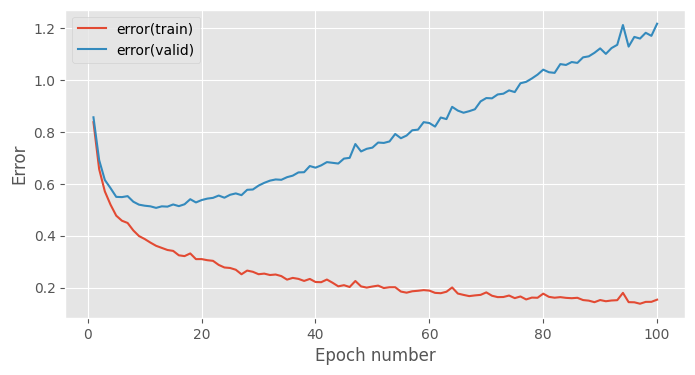

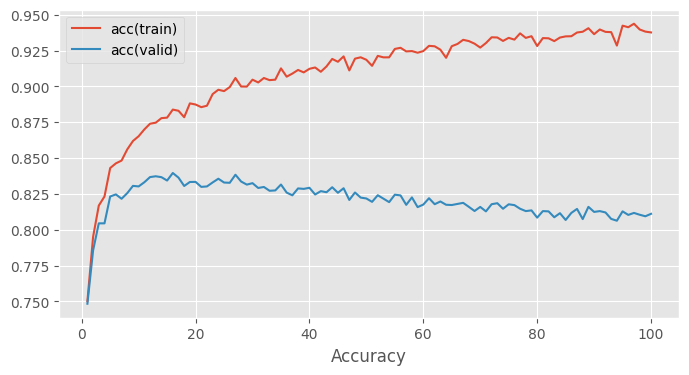

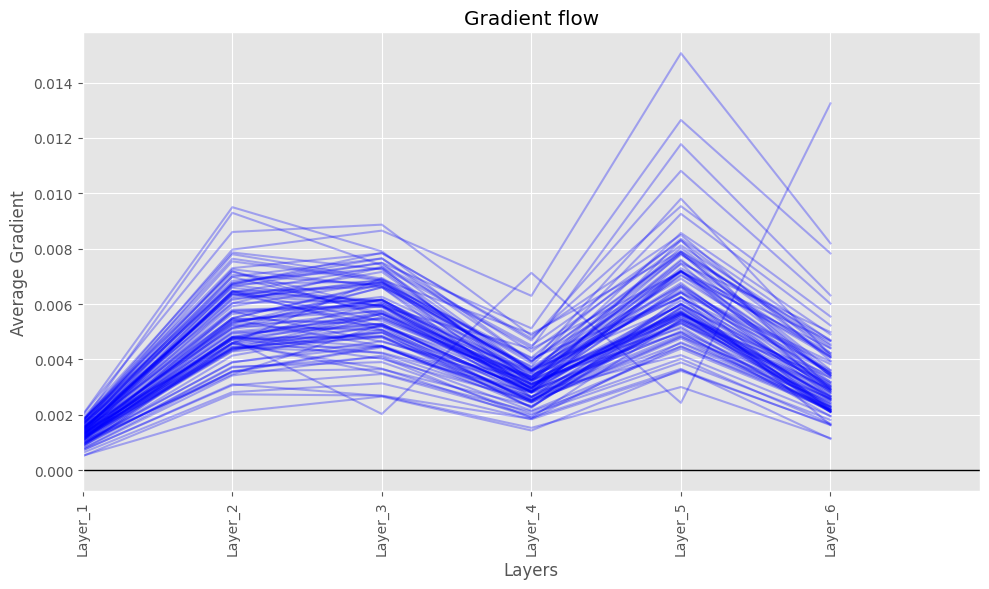

In [20]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 100

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [22]:
print("Current Working Directory:", os.getcwd())
fig_1.savefig("fig_1_v1.pdf",bbox_inches="tight",format="pdf")
fig_2.savefig("fig_2_v1.pdf",bbox_inches="tight",format="pdf")

Current Working Directory: C:\Users\User\mlpractical\notebooks


In [14]:
#setup hyperparameters
learning_rate = 0.1
num_epochs = 1
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 100

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])
models = []
error = CrossEntropySoftmaxError()
# Use a basic gradient descent learning rule
learning_rule = AdamLearningRule()

#Remember to use notebook=False when you write a script to be run in a terminal
stats,keys = train_model(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
models.append((stats,keys,1)) #Since there is only 1 hidden_layer

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.6s to complete
    error(train)=8.17e-01, acc(train)=7.58e-01, error(valid)=8.38e-01, acc(valid)=7.49e-01


In [15]:
def plot_maxout(models,stats_interval,notebook=True):
    #Value to be varried could be width,depth,L1/L2
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    
    for k in ['error(train)','error(valid)']:
        for stats,keys in models: #parameter_val is the numeric value of the value_to_be_varried
            if k == 'error(train)':
                ax_1.plot(np.arange(1, stats.shape[0])*stats_interval,stats[1:,keys[k]],
                         label=k)
            else:
                ax_1.plot(np.arange(1, stats.shape[0])*stats_interval,stats[1:,keys[k]],'--',
                         label=k)
                
    ax_1.legend(loc="upper center",bbox_to_anchor=(0.5,-0.2))
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')
    
    for k in ['acc(train)','acc(valid)']:
        for stats,keys in models: #parameter_val is the numeric value of the value_to_be_varried
            if k == 'acc(train)':
                ax_2.plot(np.arange(1, stats.shape[0])*stats_interval,stats[1:,keys[k]],
                         label=k)
            else:
                ax_2.plot(np.arange(1, stats.shape[0])*stats_interval,stats[1:,keys[k]],'--',
                         label=k)
    
    ax_2.legend(loc="upper center",bbox_to_anchor=(0.5,-0.2))
    ax_2.set_xlabel('Epoch number')
    ax_2.set_ylabel("Accuracy")
    
    return fig_1,ax_1,fig_2,ax_2 

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 10.2s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=2.07e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 9.4s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.20e-02


...

Epoch 3: 9.5s to complete
    error(train)=3.81e+00, acc(train)=4.26e-02, error(valid)=3.81e+00, acc(valid)=4.10e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 9.2s to complete
    error(train)=3.52e+00, acc(train)=4.62e-02, error(valid)=3.52e+00, acc(valid)=4.99e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 9.2s to complete
    error(train)=3.39e+00, acc(train)=6.32e-02, error(valid)=3.40e+00, acc(valid)=6.85e-02


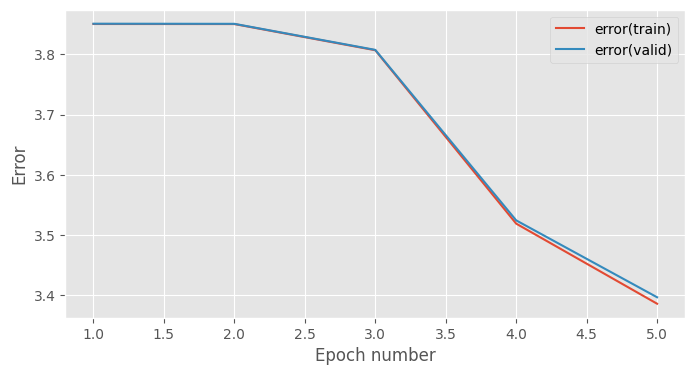

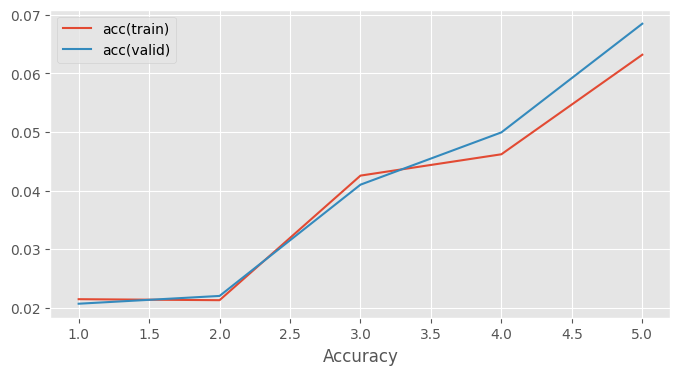

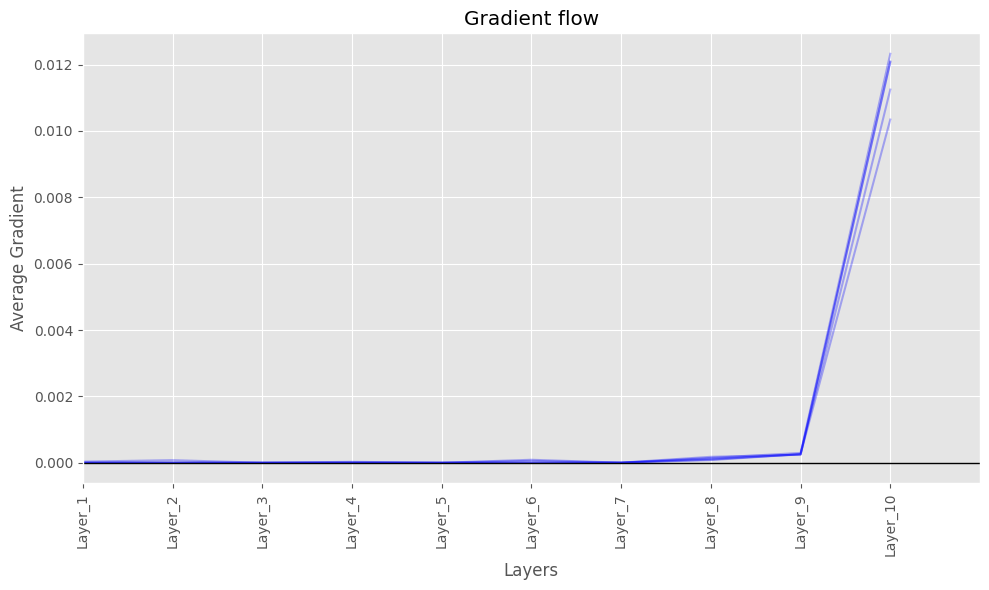

In [6]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

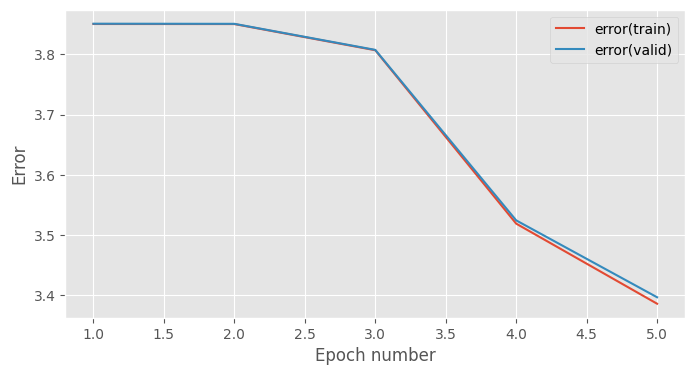

In [7]:
# You can then check the plots like this
fig_1 # The training error plot

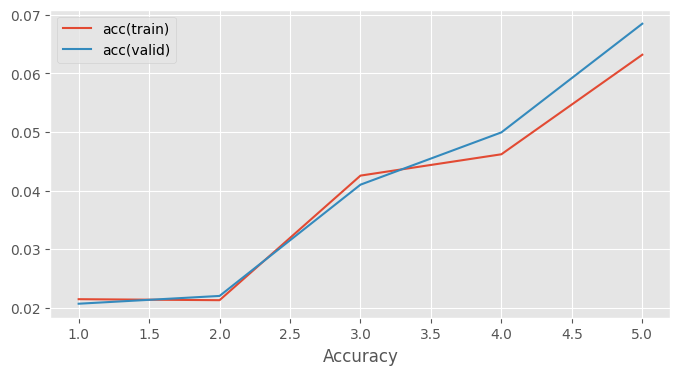

In [8]:
fig_2 # The training accuracy plot

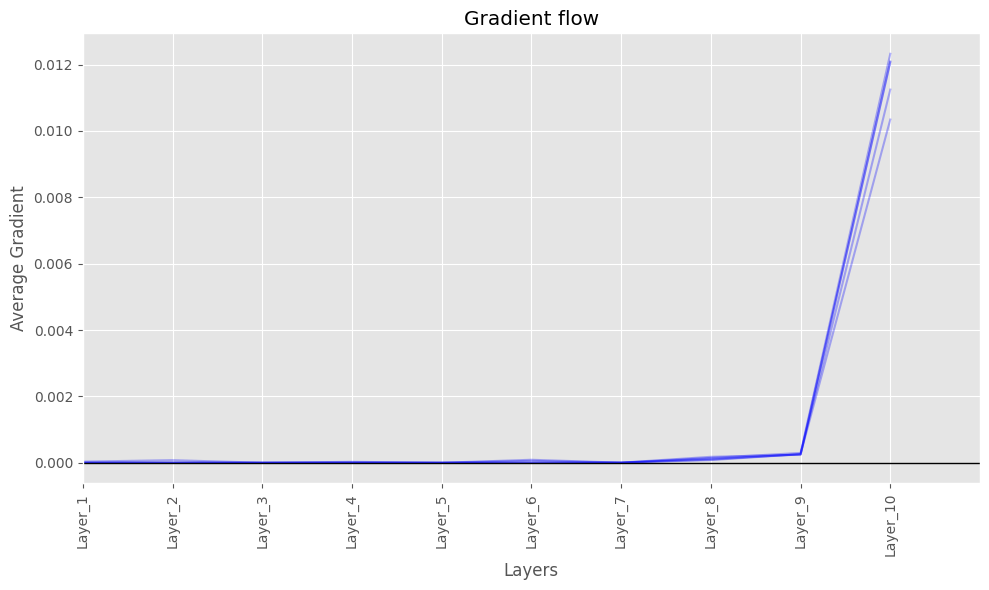

In [9]:
grad_plot # The gradient flow plot